# Stock Market Analysis & Visualization using Python

## Objective

This project focuses on collecting, analyzing, resampling, and visualizing stock market data using Python and the `yfinance`, `pandas`, and `matplotlib` libraries.

The analysis covers historical stock prices, data quality, different time intervals, resampling, adjusted close price visualization, key financial ratios, revenue, EBIT, and financial statements.

In [1]:
# ============================================================
# STEP 1 — IMPORT LIBRARIES & STOCK SELECTION
# ============================================================

# Data handling
import pandas as pd
import numpy as np

# Stock market data
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ------------------------------------------------------------
# Stock Selection
# ------------------------------------------------------------

# Selected stocks for analysis
tickers = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS"]

print("Selected Stocks:")
for ticker in tickers:
    print("-", ticker)

print("\nLibraries imported and stock selection completed successfully.")

Selected Stocks:
- RELIANCE.NS
- TCS.NS
- HDFCBANK.NS

Libraries imported and stock selection completed successfully.


In [2]:
# ============================================================
# STEP 2 — FETCH HISTORICAL STOCK DATA
# ============================================================

# Download 1 year of daily stock market data
stock_data = {}

for ticker in tickers:
    data = yf.download(
        ticker,
        period="1y",
        interval="1d",
        auto_adjust=False,
        progress=False
    )

    stock_data[ticker] = data

    print(f"\n{ticker}")
    print("-" * 50)
    print("Rows:", data.shape[0])
    print("Columns:", data.shape[1])
    print("Date Range:", data.index.min().date(), "to", data.index.max().date())

# Display sample data for each stock
for ticker, data in stock_data.items():
    print(f"\n{'=' * 70}")
    print(f"{ticker} — First 5 Records")
    print("=" * 70)
    display(data.head())


RELIANCE.NS
--------------------------------------------------
Rows: 251
Columns: 6
Date Range: 2025-09-29 to 2026-09-28

TCS.NS
--------------------------------------------------
Rows: 251
Columns: 6
Date Range: 2025-09-29 to 2026-09-28

HDFCBANK.NS
--------------------------------------------------
Rows: 251
Columns: 6
Date Range: 2025-09-29 to 2026-09-28

RELIANCE.NS — First 5 Records


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,,
2025-09-29,"1,366.48","1,372.80","1,389.00","1,368.00","1,381.60",14231999
2025-09-30,"1,357.72","1,364.00","1,377.10","1,362.80","1,377.10",14604684
2025-10-01,"1,362.40","1,368.70","1,378.60","1,362.70","1,367.00",12045916
2025-10-03,"1,357.13","1,363.40","1,371.60","1,356.90","1,363.20",12842347
2025-10-06,"1,368.67","1,375.00","1,377.40","1,359.00","1,360.00",12396580



TCS.NS — First 5 Records


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,,
2025-09-29,"2,780.67","2,896.10","2,929.30","2,894.00","2,916.00",3110035
2025-09-30,"2,773.27","2,888.40","2,915.30","2,885.10","2,911.00",2253458
2025-10-01,"2,798.04","2,914.20","2,924.80","2,866.60","2,891.00",1952902
2025-10-03,"2,786.24","2,901.90","2,924.00","2,891.10","2,924.00",2899519
2025-10-06,"2,869.29","2,988.40","2,993.60","2,895.60","2,902.00",2112774



HDFCBANK.NS — First 5 Records


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
Date,,,,,,
2025-09-29,934.84,950.30,956.80,939.10,946.05,32398179
2025-09-30,935.53,951.00,960.00,946.30,958.05,28296687
2025-10-01,949.55,965.25,969.60,946.00,952.70,25350832
2025-10-03,949.45,965.15,966.75,952.00,952.00,26658296
2025-10-06,957.61,973.45,977.40,962.00,971.90,18542683


In [3]:
# ============================================================
# STEP 3 — DATA QUALITY CHECK
# ============================================================

for ticker, data in stock_data.items():

    print("\n" + "=" * 70)
    print(f"DATA QUALITY CHECK — {ticker}")
    print("=" * 70)

    # Basic structure
    print("\n1. Dataset Shape:")
    print("Rows:", data.shape[0])
    print("Columns:", data.shape[1])

    # Date range
    print("\n2. Date Range:")
    print("Start:", data.index.min().date())
    print("End:", data.index.max().date())

    # Column names
    print("\n3. Columns:")
    print(data.columns.tolist())

    # Missing values
    print("\n4. Missing Values:")
    missing = data.isnull().sum()
    display(missing.to_frame("Missing Count"))

    # Duplicate rows
    print("5. Duplicate Rows:", data.duplicated().sum())

    # Data types
    print("\n6. Data Types:")
    print(data.dtypes)

    # Descriptive statistics
    print("\n7. Descriptive Statistics:")
    display(data.describe())

    # Quality assessment
    total_missing = data.isnull().sum().sum()
    total_duplicates = data.duplicated().sum()

    print("\n8. Data Quality Assessment:")

    if total_missing == 0 and total_duplicates == 0:
        print("✓ No missing values detected.")
        print("✓ No duplicate rows detected.")
        print("✓ Data is suitable for further analysis.")
    else:
        print("⚠ Data requires cleaning before further analysis.")


DATA QUALITY CHECK — RELIANCE.NS

1. Dataset Shape:
Rows: 251
Columns: 6

2. Date Range:
Start: 2025-09-29
End: 2026-09-28

3. Columns:
[('Adj Close', 'RELIANCE.NS'), ('Close', 'RELIANCE.NS'), ('High', 'RELIANCE.NS'), ('Low', 'RELIANCE.NS'), ('Open', 'RELIANCE.NS'), ('Volume', 'RELIANCE.NS')]

4. Missing Values:


,,Missing Count
Price,Ticker,
Adj Close,RELIANCE.NS,0
Close,RELIANCE.NS,0
High,RELIANCE.NS,0
Low,RELIANCE.NS,0
Open,RELIANCE.NS,0
Volume,RELIANCE.NS,0


5. Duplicate Rows: 0

6. Data Types:
Price      Ticker     
Adj Close  RELIANCE.NS    float64
Close      RELIANCE.NS    float64
High       RELIANCE.NS    float64
Low        RELIANCE.NS    float64
Open       RELIANCE.NS    float64
Volume     RELIANCE.NS      int64
dtype: object

7. Descriptive Statistics:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,251.00,251.00,251.00,251.00,251.00,251.00
mean,"1,383.82","1,388.27","1,400.84","1,377.28","1,389.27","13,578,550.41"
std,91.09,93.48,93.49,93.06,93.30,"6,973,976.82"
min,"1,197.60","1,197.60","1,219.70","1,197.00","1,210.50",0.00
25%,"1,310.50","1,313.20","1,324.10","1,302.45","1,314.50","8,767,894.50"
50%,"1,366.48","1,372.80","1,384.40","1,362.70","1,375.10","12,031,440.00"
75%,"1,451.49","1,458.20","1,472.00","1,444.65","1,459.20","17,327,889.50"
max,"1,584.97","1,592.30","1,611.80","1,578.20","1,593.00","42,634,247.00"



8. Data Quality Assessment:
✓ No missing values detected.
✓ No duplicate rows detected.
✓ Data is suitable for further analysis.

DATA QUALITY CHECK — TCS.NS

1. Dataset Shape:
Rows: 251
Columns: 6

2. Date Range:
Start: 2025-09-29
End: 2026-09-28

3. Columns:
[('Adj Close', 'TCS.NS'), ('Close', 'TCS.NS'), ('High', 'TCS.NS'), ('Low', 'TCS.NS'), ('Open', 'TCS.NS'), ('Volume', 'TCS.NS')]

4. Missing Values:


...


8. Data Quality Assessment:
✓ No missing values detected.
✓ No duplicate rows detected.
✓ Data is suitable for further analysis.

DATA QUALITY CHECK — HDFCBANK.NS

1. Dataset Shape:
Rows: 251
Columns: 6

2. Date Range:
Start: 2025-09-29
End: 2026-09-28

3. Columns:
[('Adj Close', 'HDFCBANK.NS'), ('Close', 'HDFCBANK.NS'), ('High', 'HDFCBANK.NS'), ('Low', 'HDFCBANK.NS'), ('Open', 'HDFCBANK.NS'), ('Volume', 'HDFCBANK.NS')]

4. Missing Values:


,,Missing Count
Price,Ticker,
Adj Close,HDFCBANK.NS,0
Close,HDFCBANK.NS,0
High,HDFCBANK.NS,0
Low,HDFCBANK.NS,0
Open,HDFCBANK.NS,0
Volume,HDFCBANK.NS,0


5. Duplicate Rows: 0

6. Data Types:
Price      Ticker     
Adj Close  HDFCBANK.NS    float64
Close      HDFCBANK.NS    float64
High       HDFCBANK.NS    float64
Low        HDFCBANK.NS    float64
Open       HDFCBANK.NS    float64
Volume     HDFCBANK.NS      int64
dtype: object

7. Descriptive Statistics:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
count,251.00,251.00,251.00,251.00,251.00,251.00
mean,841.26,851.62,859.00,844.84,851.03,"31,279,093.51"
std,101.12,106.04,106.04,105.70,106.05,"18,544,899.50"
min,687.10,687.10,694.50,681.90,683.90,0.00
25%,746.97,753.80,760.23,747.27,754.33,"19,868,274.50"
50%,808.30,811.75,819.70,806.50,811.40,"27,720,358.00"
75%,953.58,969.35,978.20,959.00,970.95,"38,790,805.50"
max,993.08,"1,009.50","1,020.50","1,006.00","1,017.50","171,637,393.00"



8. Data Quality Assessment:
✓ No missing values detected.
✓ No duplicate rows detected.
✓ Data is suitable for further analysis.


In [4]:
# ============================================================
# STEP 4 — DIFFERENT PERIODS & INTERVALS
# ============================================================

test_ticker = "RELIANCE.NS"

# Different period and interval combinations
data_1d = yf.download(
    test_ticker,
    period="1mo",
    interval="1d",
    auto_adjust=False,
    progress=False
)

data_1h = yf.download(
    test_ticker,
    period="1mo",
    interval="1h",
    auto_adjust=False,
    progress=False
)

data_5d = yf.download(
    test_ticker,
    period="5d",
    interval="1m",
    auto_adjust=False,
    progress=False
)

print("=" * 70)
print("DIFFERENT PERIOD & INTERVAL COMPARISON")
print("=" * 70)

print("\n1. 1 Month — Daily Interval")
print("Rows:", len(data_1d))
print("Date Range:", data_1d.index.min(), "to", data_1d.index.max())

print("\n2. 1 Month — Hourly Interval")
print("Rows:", len(data_1h))
print("Date Range:", data_1h.index.min(), "to", data_1h.index.max())

print("\n3. 5 Days — 1 Minute Interval")
print("Rows:", len(data_5d))
print("Date Range:", data_5d.index.min(), "to", data_5d.index.max())

print("\nSample of Daily Data:")
display(data_1d.head())

print("\nSample of Hourly Data:")
display(data_1h.head())

print("\nSample of 1-Minute Data:")
display(data_5d.head())

DIFFERENT PERIOD & INTERVAL COMPARISON

1. 1 Month — Daily Interval
Rows: 22
Date Range: 2026-08-28 00:00:00 to 2026-09-28 00:00:00

2. 1 Month — Hourly Interval
Rows: 137
Date Range: 2026-08-31 03:45:00+00:00 to 2026-09-28 09:45:00+00:00

3. 5 Days — 1 Minute Interval
Rows: 1804
Date Range: 2026-09-22 03:45:00+00:00 to 2026-09-28 09:45:00+00:00

Sample of Daily Data:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,,
2026-08-28,"1,287.00","1,287.00","1,291.80","1,280.00","1,284.90",6830228
2026-08-31,"1,277.00","1,277.00","1,297.60","1,271.00","1,278.70",34871137
2026-09-01,"1,309.00","1,309.00","1,311.80","1,280.00","1,285.00",12617528
2026-09-02,"1,313.10","1,313.10","1,321.90","1,293.10","1,298.00",13497841
2026-09-03,"1,302.50","1,302.50","1,316.80","1,302.50","1,313.10",9721454



Sample of Hourly Data:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Datetime,,,,,,
2026-08-31 03:45:00+00:00,"1,275.80","1,275.80","1,278.20","1,271.10","1,278.20",0
2026-08-31 04:45:00+00:00,"1,277.70","1,277.70","1,279.30","1,275.10","1,275.80",849688
2026-08-31 05:45:00+00:00,"1,283.00","1,283.00","1,286.90","1,277.50","1,277.60",1349557
2026-08-31 06:45:00+00:00,"1,287.00","1,287.00","1,288.80","1,282.40","1,283.00",729632
2026-08-31 07:45:00+00:00,"1,286.80","1,286.80","1,287.80","1,284.10","1,287.00",785593



Sample of 1-Minute Data:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Datetime,,,,,,
2026-09-22 03:45:00+00:00,"1,248.60","1,248.60","1,251.90","1,248.60","1,249.30",0
2026-09-22 03:46:00+00:00,"1,248.40","1,248.40","1,249.50","1,248.10","1,249.00",81429
2026-09-22 03:47:00+00:00,"1,246.70","1,246.70","1,248.50","1,246.70","1,248.50",38110
2026-09-22 03:48:00+00:00,"1,247.00","1,247.00","1,248.00","1,247.00","1,248.00",46469
2026-09-22 03:49:00+00:00,"1,247.00","1,247.00","1,247.30","1,247.00","1,247.00",25254


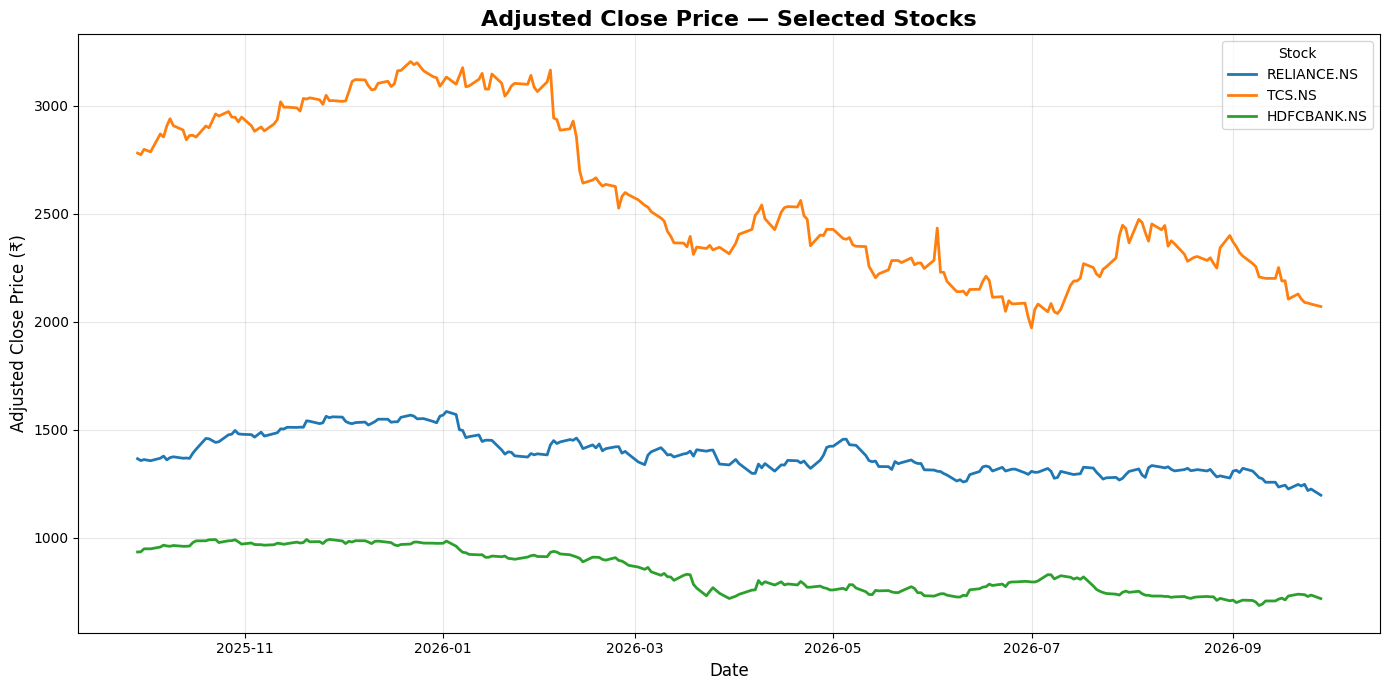

In [5]:
# ============================================================
# STEP 5 — ADJUSTED CLOSE PRICE VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 7))

for ticker, data in stock_data.items():
    plt.plot(
        data.index,
        data["Adj Close"],
        label=ticker,
        linewidth=2
    )

plt.title(
    "Adjusted Close Price — Selected Stocks",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Adjusted Close Price (₹)", fontsize=12)

plt.legend(title="Stock")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
# ============================================================
# STEP 6 — RESAMPLE STOCK DATA
# 1-Minute Data → 1-Hour Data
# ============================================================

# Copy the 1-minute RELIANCE data
minute_data = data_5d.copy()

# Handle yfinance MultiIndex columns
if isinstance(minute_data.columns, pd.MultiIndex):
    minute_data.columns = minute_data.columns.get_level_values(0)

# Remove missing rows
minute_data = minute_data.dropna()

print("Available Columns:")
print(minute_data.columns.tolist())

# Resample OHLCV data to 1-hour frequency
hourly_data = minute_data.resample("1h").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
    "Adj Close": "last",
    "Volume": "sum"
})

# Remove intervals with no trading data
hourly_data = hourly_data.dropna(
    subset=["Open", "High", "Low", "Close"]
)

print("\n" + "=" * 70)
print("RESAMPLED STOCK DATA — RELIANCE")
print("=" * 70)

print("\nOriginal 1-Minute Data:")
print("Rows:", len(minute_data))

print("\nResampled 1-Hour Data:")
print("Rows:", len(hourly_data))

print("\nFirst 5 Rows of 1-Hour Data:")
display(hourly_data.head())

print("\nResampled Data Shape:")
print(hourly_data.shape)

Available Columns:
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

RESAMPLED STOCK DATA — RELIANCE

Original 1-Minute Data:
Rows: 1804

Resampled 1-Hour Data:
Rows: 35

First 5 Rows of 1-Hour Data:


Price,Open,High,Low,Close,Adj Close,Volume
Datetime,,,,,,
2026-09-22 03:00:00+00:00,"1,249.30","1,251.90","1,245.00","1,245.50","1,245.50",510439
2026-09-22 04:00:00+00:00,"1,245.50","1,251.00","1,245.50","1,249.90","1,249.90",1424639
2026-09-22 05:00:00+00:00,"1,250.00","1,250.20","1,246.00","1,248.60","1,248.60",1129257
2026-09-22 06:00:00+00:00,"1,248.60","1,248.60","1,242.60","1,244.20","1,244.20",1357669
2026-09-22 07:00:00+00:00,"1,244.50","1,245.10","1,240.80","1,242.30","1,242.30",1084085



Resampled Data Shape:
(35, 6)


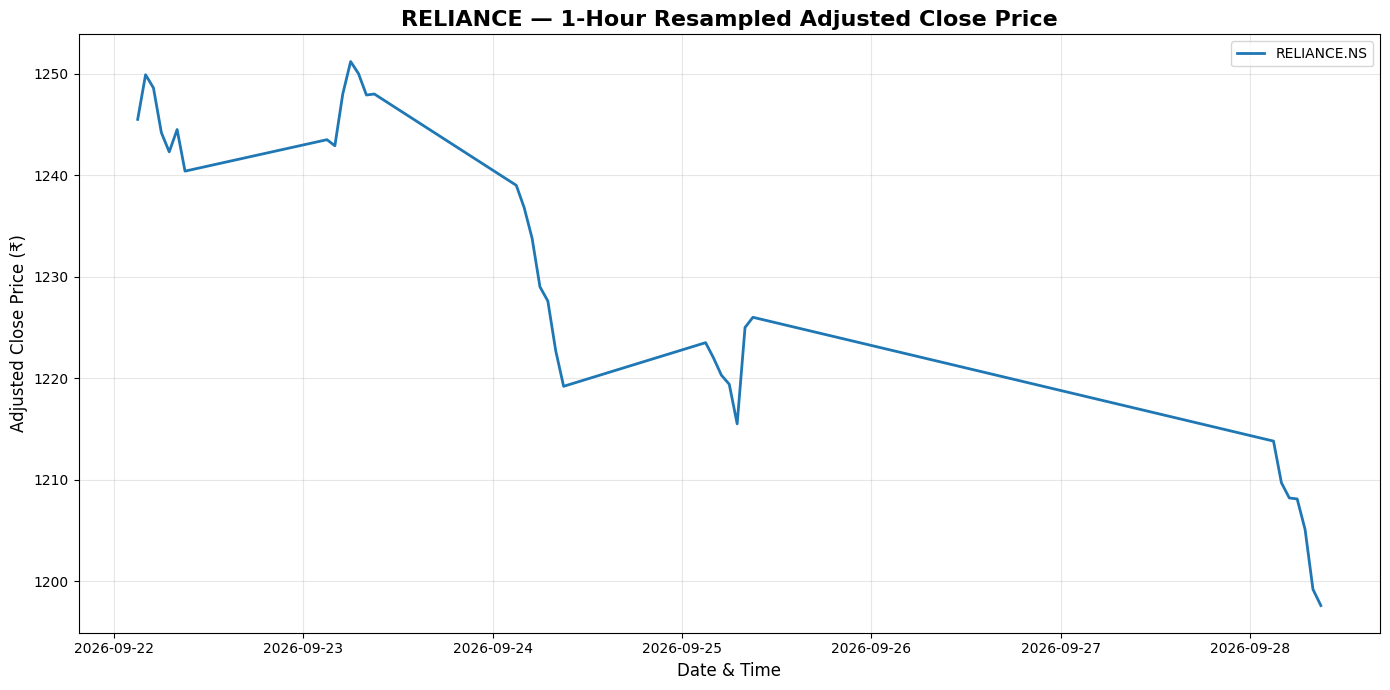

In [8]:
# ============================================================
# STEP 7 — VISUALIZE RESAMPLED STOCK DATA
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    hourly_data.index,
    hourly_data["Adj Close"],
    linewidth=2,
    label="RELIANCE.NS"
)

plt.title(
    "RELIANCE — 1-Hour Resampled Adjusted Close Price",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date & Time", fontsize=12)
plt.ylabel("Adjusted Close Price (₹)", fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# STEP 8 — FUNDAMENTAL ANALYSIS
# P/E RATIO & P/B RATIO
# ============================================================

fundamental_data = []

for ticker in tickers:

    stock = yf.Ticker(ticker)
    info = stock.info

    fundamental_data.append({
        "Ticker": ticker,
        "Company": info.get("longName", ticker),
        "P/E Ratio": info.get("trailingPE"),
        "P/B Ratio": info.get("priceToBook")
    })

# Create a DataFrame
fundamental_df = pd.DataFrame(fundamental_data)

print("=" * 70)
print("KEY FUNDAMENTAL RATIOS")
print("=" * 70)

display(fundamental_df)

KEY FUNDAMENTAL RATIOS


,Ticker,Company,P/E Ratio,P/B Ratio
0,RELIANCE.NS,Reliance Industries Limited,21.71,1.79
1,TCS.NS,Tata Consultancy Services Limited,15.05,6.83
2,HDFCBANK.NS,HDFC Bank Limited,15.72,1.83


ANNUAL REVENUE


,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
RELIANCE.NS,NaN,"8,778,350,000,000.00","9,010,640,000,000.00","9,646,930,000,000.00","10,572,190,000,000.00"
TCS.NS,NaN,"2,254,580,000,000.00","2,408,930,000,000.00","2,553,240,000,000.00","2,670,210,000,000.00"
HDFCBANK.NS,NaN,"1,205,375,000,000.00","1,604,968,500,000.00","1,838,641,100,000.00","1,925,667,800,000.00"


<Figure size 1200x700 with 0 Axes>

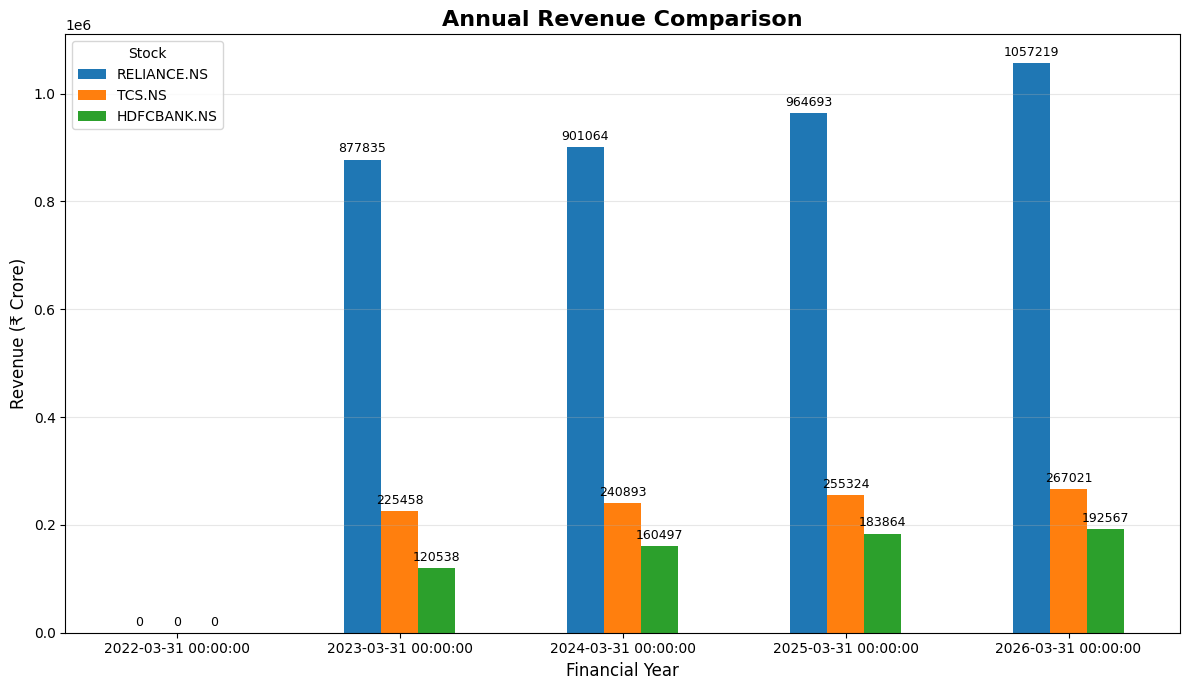

In [10]:
# ============================================================
# STEP 9 — REVENUE ANALYSIS
# ============================================================

revenue_data = {}

for ticker in tickers:
    stock = yf.Ticker(ticker)

    # Fetch annual financial statements
    financials = stock.financials

    # Extract Total Revenue
    if "Total Revenue" in financials.index:
        revenue = financials.loc["Total Revenue"]
        revenue_data[ticker] = revenue

# Create Revenue DataFrame
revenue_df = pd.DataFrame(revenue_data).T

print("=" * 70)
print("ANNUAL REVENUE")
print("=" * 70)

display(revenue_df)

# ------------------------------------------------------------
# Revenue Visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

# Convert to ₹ Crore for easier interpretation
revenue_crore = revenue_df / 1e7

ax = revenue_crore.T.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Annual Revenue Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Financial Year", fontsize=12)
plt.ylabel("Revenue (₹ Crore)", fontsize=12)

plt.xticks(rotation=0)
plt.legend(title="Stock")
plt.grid(axis="y", alpha=0.3)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

ANNUAL EBIT


,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
RELIANCE.NS,NaN,"1,130,040,000,000.00","1,261,120,000,000.00","1,281,380,000,000.00","1,472,180,000,000.00"
TCS.NS,NaN,"576,860,000,000.00","627,750,000,000.00","661,270,000,000.00","667,140,000,000.00"


<Figure size 1200x700 with 0 Axes>

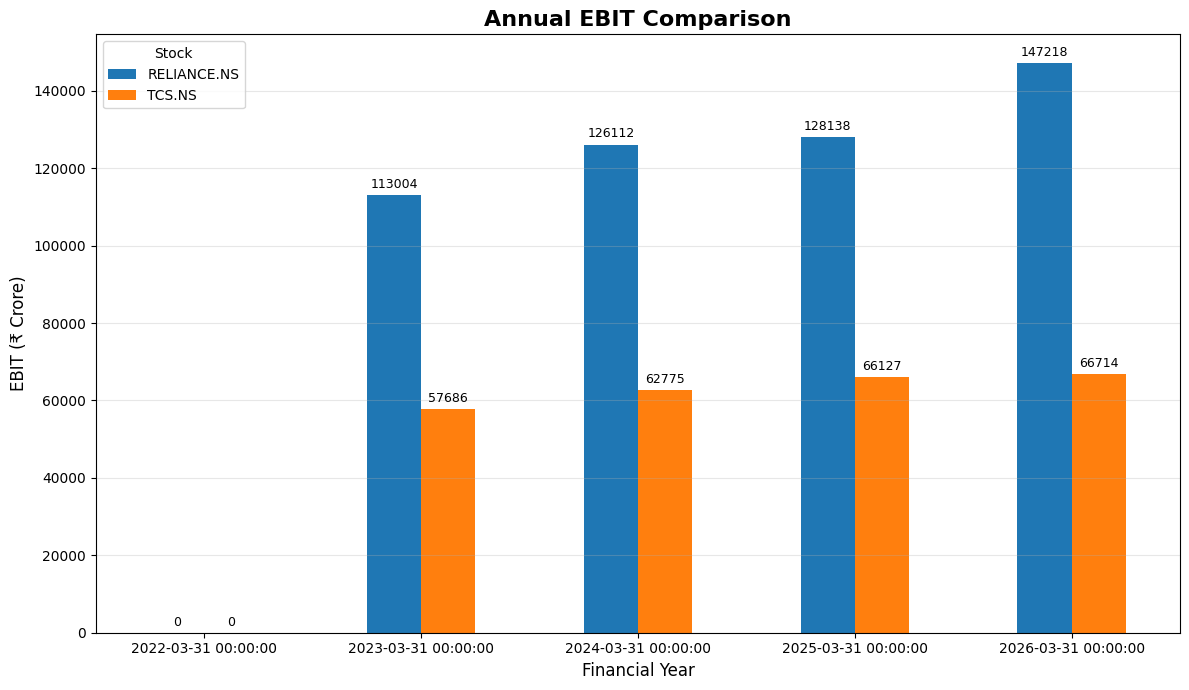

In [11]:
# ============================================================
# STEP 10 — EBIT ANALYSIS
# ============================================================

ebit_data = {}

for ticker in tickers:
    stock = yf.Ticker(ticker)

    # Fetch annual financial statements
    financials = stock.financials

    # Extract EBIT
    if "EBIT" in financials.index:
        ebit = financials.loc["EBIT"]
        ebit_data[ticker] = ebit

# Create EBIT DataFrame
ebit_df = pd.DataFrame(ebit_data).T

print("=" * 70)
print("ANNUAL EBIT")
print("=" * 70)

display(ebit_df)

# ------------------------------------------------------------
# EBIT Visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

# Convert to ₹ Crore
ebit_crore = ebit_df / 1e7

ax = ebit_crore.T.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Annual EBIT Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Financial Year", fontsize=12)
plt.ylabel("EBIT (₹ Crore)", fontsize=12)

plt.xticks(rotation=0)
plt.legend(title="Stock")
plt.grid(axis="y", alpha=0.3)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# STEP 11 — FINANCIAL STATEMENTS & COMPANY INFORMATION
# ============================================================

financial_statements = {}

for ticker in tickers:

    stock = yf.Ticker(ticker)

    print("\n" + "=" * 80)
    print(f"FINANCIAL INFORMATION — {ticker}")
    print("=" * 80)

    # --------------------------------------------------------
    # Income Statement
    # --------------------------------------------------------
    print("\n1. INCOME STATEMENT / FINANCIALS")
    income_statement = stock.financials
    display(income_statement)

    # --------------------------------------------------------
    # Balance Sheet
    # --------------------------------------------------------
    print("\n2. BALANCE SHEET")
    balance_sheet = stock.balance_sheet
    display(balance_sheet)

    # --------------------------------------------------------
    # Cash Flow Statement
    # --------------------------------------------------------
    print("\n3. CASH FLOW STATEMENT")
    cash_flow = stock.cashflow
    display(cash_flow)

    # --------------------------------------------------------
    # Company Information
    # --------------------------------------------------------
    print("\n4. COMPANY INFORMATION")
    company_info = stock.info

    # Display selected useful information
    selected_info = {
        "Company Name": company_info.get("longName"),
        "Sector": company_info.get("sector"),
        "Industry": company_info.get("industry"),
        "Current Price": company_info.get("currentPrice"),
        "Market Cap": company_info.get("marketCap"),
        "Currency": company_info.get("currency")
    }

    display(pd.DataFrame(
        selected_info.items(),
        columns=["Metric", "Value"]
    ))

    # Store everything for later analysis
    financial_statements[ticker] = {
        "income_statement": income_statement,
        "balance_sheet": balance_sheet,
        "cash_flow": cash_flow,
        "company_info": company_info
    }


FINANCIAL INFORMATION — RELIANCE.NS

1. INCOME STATEMENT / FINANCIALS


,2026-03-31,2025-03-31,2024-03-31,2023-03-31,2022-03-31
Tax Effect Of Unusual Items,"6,330,710,000.00","3,339,140,000.00","4,065,480,000.00","-3,185,730,000.00",NaN
Tax Rate For Calcs,0.22,0.24,0.25,0.22,NaN
Normalized EBITDA,"2,020,760,000,000.00","1,798,710,000,000.00","1,752,880,000,000.00","1,547,650,000,000.00",NaN
Total Unusual Items,"28,300,000,000.00","14,030,000,000.00","16,560,000,000.00","-14,580,000,000.00",NaN
Total Unusual Items Excluding Goodwill,"28,300,000,000.00","14,030,000,000.00","16,560,000,000.00","-14,580,000,000.00",NaN
Net Income From Continuing Operation Net Minority Interest,"807,750,000,000.00","696,480,000,000.00","696,210,000,000.00","662,840,000,000.00",NaN
Reconciled Depreciation,"576,880,000,000.00","531,360,000,000.00","508,320,000,000.00","403,030,000,000.00",NaN
Reconciled Cost Of Revenue,"7,868,240,000,000.00","7,226,870,000,000.00","6,745,990,000,000.00","6,718,980,000,000.00",NaN
EBITDA,"2,049,060,000,000.00","1,812,740,000,000.00","1,769,440,000,000.00","1,533,070,000,000.00",NaN
EBIT,"1,472,180,000,000.00","1,281,380,000,000.00","1,261,120,000,000.00","1,130,040,000,000.00",NaN



2. BALANCE SHEET


,2026-03-31,2025-03-31,2024-03-31,2023-03-31,2022-03-31
Ordinary Shares Number,"13,532,472,634.00","13,532,871,488.00","13,532,218,028.00","13,532,188,028.00",NaN
Share Issued,"13,532,472,634.00","13,532,871,488.00","13,532,218,028.00","13,532,188,028.00",NaN
Net Debt,"2,370,940,000,000.00","2,468,850,000,000.00","2,310,820,000,000.00","2,798,100,000,000.00",NaN
Total Debt,"3,980,000,000,000.00","3,695,750,000,000.00","3,461,420,000,000.00","3,343,920,000,000.00",NaN
Tangible Book Value,"4,849,230,000,000.00","4,342,610,000,000.00","4,331,070,000,000.00","3,850,770,000,000.00",NaN
...,...,...,...,...,...
Cash Cash Equivalents And Short Term Investments,"2,772,120,000,000.00","2,387,920,000,000.00","2,113,100,000,000.00","1,612,330,000,000.00",NaN
Other Short Term Investments,"1,398,850,000,000.00","1,381,470,000,000.00","1,177,700,000,000.00","1,270,770,000,000.00",NaN
Cash And Cash Equivalents,"1,373,270,000,000.00","1,006,450,000,000.00","935,400,000,000.00","341,560,000,000.00",NaN
Cash Equivalents,"38,750,000,000.00","541,600,000,000.00","195,280,000,000.00","301,840,000,000.00",NaN



3. CASH FLOW STATEMENT


...

,2026-03-31,2025-03-31,2024-03-31,2023-03-31
Treasury Shares Number,"107,566.00","17,069.00","12,035.00",NaN
Ordinary Shares Number,"15,393,260,762.00","15,304,409,210.00","15,193,797,254.00","11,159,485,572.00"
Share Issued,"15,393,368,328.00","15,304,443,348.00","15,193,821,324.00","11,159,485,572.00"
Net Debt,"2,818,408,500,000.00","3,949,853,200,000.00","4,536,535,800,000.00","690,213,700,000.00"
Total Debt,"6,643,640,400,000.00","7,326,106,100,000.00","8,093,552,100,000.00","3,151,792,800,000.00"
Tangible Book Value,"5,187,686,900,000.00","4,676,501,100,000.00","3,921,699,900,000.00","2,837,262,800,000.00"
Invested Capital,"14,636,478,000,000.00","14,849,067,700,000.00","14,909,836,500,000.00","5,966,334,600,000.00"
Net Tangible Assets,"5,187,686,900,000.00","4,676,501,100,000.00","3,921,699,900,000.00","2,837,262,800,000.00"
Capital Lease Obligations,"174,558,000,000.00","153,929,800,000.00","131,043,000,000.00","97,658,900,000.00"
Common Stock Equity,"8,167,395,600,000.00","7,676,891,400,000.00","6,947,327,400,000.00","2,912,200,700,000.00"



3. CASH FLOW STATEMENT


,2026-03-31,2025-03-31,2024-03-31,2023-03-31
Free Cash Flow,"1,065,776,300,000.00","1,129,220,100,000.00","968,484,400,000.00","433,580,300,000.00"
Repurchase Of Capital Stock,NaN,NaN,"-2,300,000,000.00",NaN
Repayment Of Debt,"-1,701,295,800,000.00","-1,463,100,800,000.00","-1,400,297,900,000.00","-558,113,600,000.00"
Issuance Of Debt,"860,672,100,000.00","661,226,300,000.00","1,155,775,200,000.00","1,022,933,100,000.00"
Issuance Of Capital Stock,NaN,NaN,"75,997,300,000.00",NaN
...,...,...,...,...
Gain Loss On Investment Securities,"-50,331,900,000.00","-6,825,000,000.00","-826,700,000.00","720,300,000.00"
Net Foreign Currency Exchange Gain Loss,"46,618,900,000.00","20,184,600,000.00","5,554,300,000.00","276,700,000.00"
Gain Loss On Sale Of PPE,"-1,880,100,000.00","-224,900,000.00","-748,000,000.00","-80,600,000.00"
Gain Loss On Sale Of Business,NaN,NaN,"-73,414,200,000.00",NaN



4. COMPANY INFORMATION


,Metric,Value
0,Company Name,HDFC Bank Limited
1,Sector,Financial Services
2,Industry,Banks - Regional
3,Current Price,719.05
4,Market Cap,11086654865408
5,Currency,INR


In [13]:
# ============================================================
# STEP 12 — COMPARATIVE FUNDAMENTAL ANALYSIS
# ============================================================

# Create a compact comparison table
comparison_df = fundamental_df.copy()

# Add latest annual revenue
latest_revenue = {}

for ticker in tickers:
    if ticker in revenue_df.index:
        revenue_series = revenue_df.loc[ticker].dropna()
        if len(revenue_series) > 0:
            latest_revenue[ticker] = revenue_series.iloc[0] / 1e7
        else:
            latest_revenue[ticker] = np.nan

# Add latest annual EBIT
latest_ebit = {}

for ticker in tickers:
    if ticker in ebit_df.index:
        ebit_series = ebit_df.loc[ticker].dropna()
        if len(ebit_series) > 0:
            latest_ebit[ticker] = ebit_series.iloc[0] / 1e7
        else:
            latest_ebit[ticker] = np.nan

comparison_df["Latest Revenue (₹ Cr)"] = (
    comparison_df["Ticker"].map(latest_revenue)
)

comparison_df["Latest EBIT (₹ Cr)"] = (
    comparison_df["Ticker"].map(latest_ebit)
)

print("=" * 80)
print("COMPARATIVE FUNDAMENTAL ANALYSIS")
print("=" * 80)

display(comparison_df)

COMPARATIVE FUNDAMENTAL ANALYSIS


,Ticker,Company,P/E Ratio,P/B Ratio,Latest Revenue (₹ Cr),Latest EBIT (₹ Cr)
0,RELIANCE.NS,Reliance Industries Limited,21.71,1.79,"877,835.00","113,004.00"
1,TCS.NS,Tata Consultancy Services Limited,15.05,6.83,"225,458.00","57,686.00"
2,HDFCBANK.NS,HDFC Bank Limited,15.72,1.83,"120,537.50",NaN


# Conclusion

This project demonstrates the use of Python and the `yfinance` library for collecting and analyzing stock market data.

The analysis covered:

- Historical stock market data collection for selected stocks
- Data quality assessment
- Different historical periods and data intervals
- Adjusted close price visualization using Matplotlib
- Resampling of minute-level stock data into hourly data
- Price-to-Earnings (P/E) and Price-to-Book (P/B) ratios
- Annual revenue analysis and visualization
- EBIT analysis and visualization
- Income statements, balance sheets, and cash flow statements
- Comparative analysis of selected companies

Overall, the project demonstrates how Python can be used to combine time-series market data with fundamental financial information to perform structured stock market analysis and visualization.
